In [58]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.metrics as metrics 
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
import matplotlib.pyplot as plt
import math
import warnings
import xgboost as xgb
warnings.filterwarnings("ignore", category=FutureWarning)
import matplotlib.pyplot as plt
#!pip install statsmodels
#!pip install xgboost
import statsmodels.api as sm
%matplotlib inline

In [59]:
## Data

In [60]:
df = pd.read_pickle("df_after_feature_eng_1.pkl")
print(df.isnull().sum())  # Should match the saved df

track_id                         0
track_popularity                 0
track_album_id                   0
danceability                     0
energy                           0
key                              0
loudness                         0
mode                             0
speechiness                      0
acousticness                     0
instrumentalness                 0
liveness                         0
valence                          0
tempo                            0
playlist_count_per_song          0
duration_minutes                 0
playlist_genre_count_per_song    0
track_album_release_year         0
track_album_release_month        0
language_category                0
track_artist_type                0
dtype: int64


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28356 entries, 0 to 32832
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   track_id                       28356 non-null  string 
 1   track_popularity               28356 non-null  int64  
 2   track_album_id                 28356 non-null  string 
 3   danceability                   28356 non-null  float64
 4   energy                         28356 non-null  float64
 5   key                            28356 non-null  int64  
 6   loudness                       28356 non-null  float64
 7   mode                           28356 non-null  int64  
 8   speechiness                    28356 non-null  float64
 9   acousticness                   28356 non-null  float64
 10  instrumentalness               28356 non-null  float64
 11  liveness                       28356 non-null  float64
 12  valence                        28356 non-null  floa

In [62]:
### Encoding Categorial 

In [63]:
 ## transforming object and encoding 

In [64]:
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder instance
label_encoder = LabelEncoder()

# Process all object or string columns
for column in df.columns:
    if df[column].dtype == 'object' or df[column].dtype == 'string':  # Check for object or string type
        df.loc[:, column] = label_encoder.fit_transform(df[column].astype(str))  # Apply LabelEncoder


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28356 entries, 0 to 32832
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   track_id                       28356 non-null  int32  
 1   track_popularity               28356 non-null  int64  
 2   track_album_id                 28356 non-null  int32  
 3   danceability                   28356 non-null  float64
 4   energy                         28356 non-null  float64
 5   key                            28356 non-null  int64  
 6   loudness                       28356 non-null  float64
 7   mode                           28356 non-null  int64  
 8   speechiness                    28356 non-null  float64
 9   acousticness                   28356 non-null  float64
 10  instrumentalness               28356 non-null  float64
 11  liveness                       28356 non-null  float64
 12  valence                        28356 non-null  floa

In [66]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['language_category'] = label_encoder.fit_transform(df['language_category'].astype(str))
df['track_artist_type'] = label_encoder.fit_transform(df['track_artist_type'].astype(str))


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28356 entries, 0 to 32832
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   track_id                       28356 non-null  int32  
 1   track_popularity               28356 non-null  int64  
 2   track_album_id                 28356 non-null  int32  
 3   danceability                   28356 non-null  float64
 4   energy                         28356 non-null  float64
 5   key                            28356 non-null  int64  
 6   loudness                       28356 non-null  float64
 7   mode                           28356 non-null  int64  
 8   speechiness                    28356 non-null  float64
 9   acousticness                   28356 non-null  float64
 10  instrumentalness               28356 non-null  float64
 11  liveness                       28356 non-null  float64
 12  valence                        28356 non-null  floa

In [68]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
track_id,28356.0,14177.500000,8185.816453,0.000,7088.750000,14177.500000,21266.250000,28355.000000
track_popularity,28356.0,39.329771,23.702376,0.000,21.000000,42.000000,58.000000,100.000000
track_album_id,28356.0,11260.283503,6500.369980,0.000,5627.000000,11237.500000,16870.250000,22544.000000
danceability,28356.0,0.672183,0.092506,0.462,0.612000,0.672183,0.737000,0.859000
energy,28356.0,0.734714,0.130118,0.447,0.647000,0.734714,0.835000,0.975000
key,28356.0,5.368000,3.613904,0.000,2.000000,6.000000,9.000000,11.000000
loudness,28356.0,-6.134498,1.634820,-10.109,-7.098000,-6.134498,-4.966750,-2.909000
mode,28356.0,0.565489,0.495701,0.000,0.000000,1.000000,1.000000,1.000000
speechiness,28356.0,0.065721,0.033201,0.000,0.041000,0.062600,0.073000,0.179000
acousticness,28356.0,0.092012,0.093090,0.000,0.014375,0.079700,0.122000,0.382000


In [69]:
#df.isna().sum()

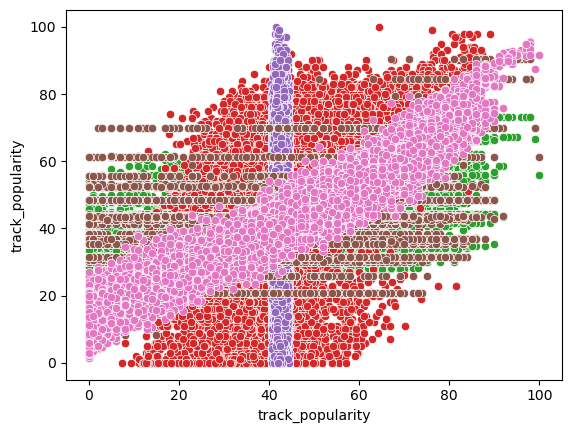

In [70]:
import matplotlib.pyplot as plt

plt.show()

In [71]:
df.corr(method='spearman')

,track_id,track_popularity,track_album_id,danceability,energy,key,loudness,mode,speechiness,acousticness,...,liveness,valence,tempo,playlist_count_per_song,duration_minutes,playlist_genre_count_per_song,track_album_release_year,track_album_release_month,language_category,track_artist_type
track_id,1.000000,0.011475,-0.001915,0.000031,-0.010119,-0.005386,-0.004861,-0.006645,-0.002442,0.015262,...,0.004308,0.001704,-0.006748,0.005335,0.003488,0.006661,-0.002013,0.008356,0.010071,-0.010151
track_popularity,0.011475,1.000000,0.005843,0.031744,-0.094594,-0.008439,0.040044,0.017713,-0.000611,0.118290,...,-0.029201,0.025820,-0.009526,0.294719,-0.121303,0.276797,0.131255,0.072088,0.024119,-0.040182
track_album_id,-0.001915,0.005843,1.000000,0.005621,-0.000491,0.003516,0.000675,0.002736,-0.010585,0.006929,...,-0.003445,-0.002415,0.000385,-0.000493,-0.022909,0.002586,0.017254,-0.003027,-0.008199,-0.007365
danceability,0.000031,0.031744,0.005621,1.000000,-0.127824,0.008360,-0.059807,-0.038817,0.187830,0.128031,...,-0.095850,0.243592,-0.120453,0.017580,-0.035289,0.005354,0.042995,0.028319,0.068602,-0.003905
energy,-0.010119,-0.094594,-0.000491,-0.127824,1.000000,0.002615,0.441702,0.009214,0.081293,-0.310524,...,0.115109,0.061090,0.141381,-0.010396,-0.024890,-0.003259,-0.023972,-0.027393,-0.029996,0.048191
key,-0.005386,-0.008439,0.003516,0.008360,0.002615,1.000000,-0.005306,-0.171163,0.018705,0.007543,...,-0.001383,0.019656,-0.013530,0.000181,0.016857,-0.005042,-0.003468,0.003454,0.005220,0.004081
loudness,-0.004861,0.040044,0.000675,-0.059807,0.441702,-0.005306,1.000000,-0.010851,0.098949,-0.152738,...,0.059739,0.027801,0.083520,0.064930,-0.105601,0.062844,0.049403,0.014888,0.009327,0.038466
mode,-0.006645,0.017713,0.002736,-0.038817,0.009214,-0.171163,-0.010851,1.000000,-0.073642,-0.021641,...,-0.004715,-0.003339,0.014028,0.000462,0.015588,0.007515,-0.035603,-0.029348,-0.017851,-0.023228
speechiness,-0.002442,-0.000611,-0.010585,0.187830,0.081293,0.018705,0.098949,-0.073642,1.000000,0.015210,...,0.046627,0.059401,0.042932,0.012998,-0.127707,0.003388,0.098821,0.043078,0.063966,0.058858
acousticness,0.015262,0.118290,0.006929,0.128031,-0.310524,0.007543,-0.152738,-0.021641,0.015210,1.000000,...,-0.047501,0.143757,-0.145108,0.026013,-0.065477,0.011221,0.039163,0.027515,0.083247,-0.059873


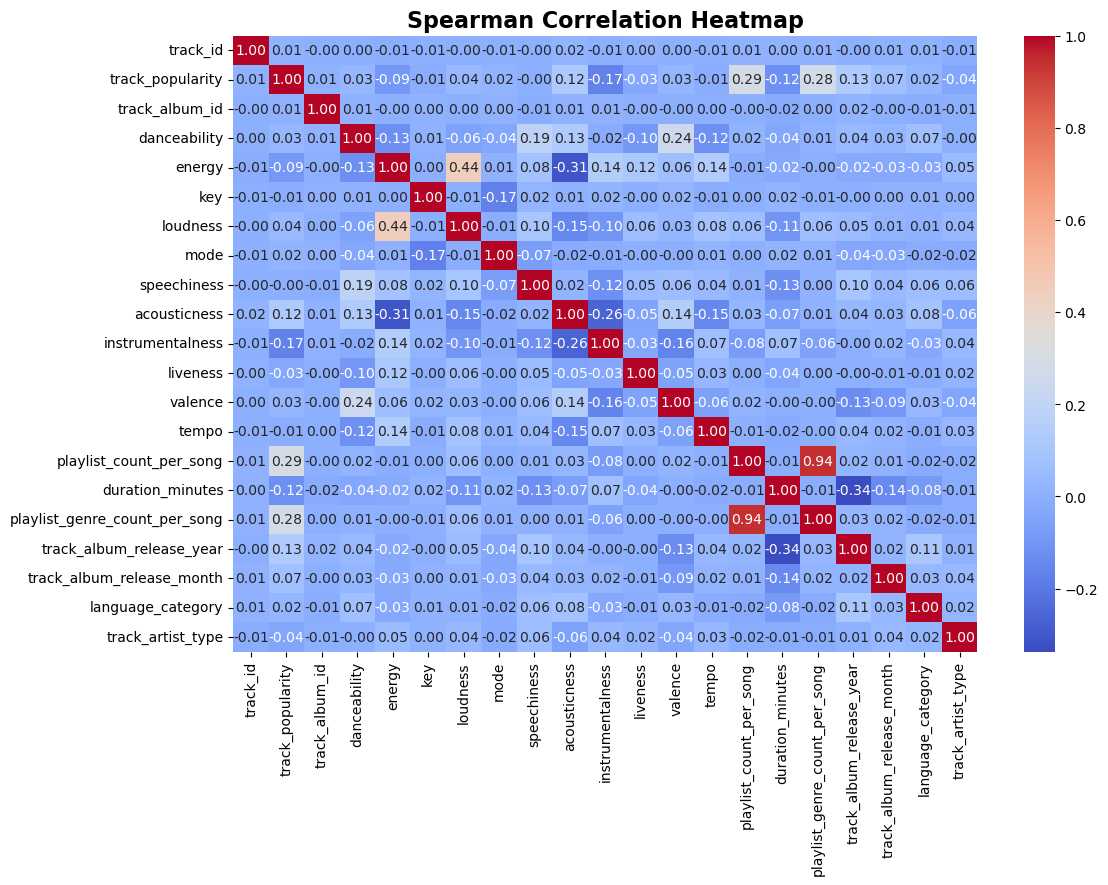

In [72]:

# Calculate the Spearman correlation matrix
spearman_corr = df.corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(12, 8))  # Set the figure size for better readability
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Spearman Correlation Heatmap', fontsize=16, fontweight='bold')  # Add a title
plt.show()


In [73]:
X = df.loc[:,df.columns != 'track_popularity']
y = df['track_popularity']

In [74]:
def regressionMetrics(y, yhat):
    res = {'MSE': metrics.mean_squared_error(y,yhat),
           'RMSE': np.sqrt(metrics.mean_squared_error(y,yhat)),
           'MAE': metrics.mean_absolute_error(y,yhat),
           'RMSLE': np.sqrt(metrics.mean_squared_log_error(y,yhat)),
           'r2' :   r2_score(y, yhat)
          }
    return res

In [75]:
## Regression Models

In [76]:
models_list = pd.DataFrame()

In [77]:
model_dict = {'model': "Linear Regression"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred1)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MSE,RMSE,MAE,RMSLE,r2
0,Linear Regression,461.293834,21.477752,17.918885,1.298968,0.178875


In [78]:
sns.scatterplot(x=y, y=pred1)

<Axes: xlabel='track_popularity'>

### Decision Tree

In [79]:
from sklearn.tree import DecisionTreeRegressor
mod1 = DecisionTreeRegressor(max_depth=5)  
mod1.fit(X, y)


DecisionTreeRegressor(max_depth=5)

In [80]:
pred1 = mod1.predict(X)
model_dict = {'model': "Decision Tree"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred1)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MSE,RMSE,MAE,RMSLE,r2
0,Linear Regression,461.293834,21.477752,17.918885,1.298968,0.178875
1,Decision Tree,461.293834,21.477752,17.918885,1.298968,0.178875


In [81]:
sns.scatterplot(x=y, y=pred1)


<Axes: xlabel='track_popularity'>

### Random Forest

In [82]:
mod2 = RandomForestRegressor(random_state=1)
mod2.fit(X,y)

RandomForestRegressor(random_state=1)

In [83]:
pred2 = mod2.predict(X)
model_dict = {'model': "RandomForest"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred2)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MSE,RMSE,MAE,RMSLE,r2
0,Linear Regression,461.293834,21.477752,17.918885,1.298968,0.178875
1,Decision Tree,461.293834,21.477752,17.918885,1.298968,0.178875
2,RandomForest,63.285062,7.955191,6.511855,0.865491,0.887350


In [84]:
sns.scatterplot(x=y, y=pred2)

<Axes: xlabel='track_popularity'>

### Adaptive Boosting (ADABoost)

In [85]:
mod4 = AdaBoostRegressor(random_state=1)
mod4.fit(X,y)

AdaBoostRegressor(random_state=1)

In [86]:
pred4 = mod4.predict(X)
model_dict = {'model': "ADABoost"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred4)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MSE,RMSE,MAE,RMSLE,r2
0,Linear Regression,461.293834,21.477752,17.918885,1.298968,0.178875
1,Decision Tree,461.293834,21.477752,17.918885,1.298968,0.178875
2,RandomForest,63.285062,7.955191,6.511855,0.865491,0.887350
3,ADABoost,476.769653,21.835056,18.582721,1.310019,0.151327


In [87]:
sns.scatterplot(x=y, y=pred4)

<Axes: xlabel='track_popularity'>

In [88]:
### Gradient Boosting Machine (GBM)

In [89]:
mod5 = GradientBoostingRegressor(random_state=1)
mod5.fit(X,y)

GradientBoostingRegressor(random_state=1)

In [90]:
pred5 = mod5.predict(X)
model_dict = {'model': "GBM"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred5)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MSE,RMSE,MAE,RMSLE,r2
0,Linear Regression,461.293834,21.477752,17.918885,1.298968,0.178875
1,Decision Tree,461.293834,21.477752,17.918885,1.298968,0.178875
2,RandomForest,63.285062,7.955191,6.511855,0.865491,0.887350
3,ADABoost,476.769653,21.835056,18.582721,1.310019,0.151327
4,GBM,433.830509,20.828598,17.365399,1.282128,0.227761


In [91]:
sns.scatterplot(y=y, x=pred5)

<Axes: xlabel='track_popularity', ylabel='track_popularity'>

In [92]:
### Support Vector Machine (SVM)

In [93]:
mod6 = SVR()
mod6.fit(X,y)


SVR()

In [94]:
pred6 = mod6.predict(X)
model_dict = {'model': "SVM"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred6)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MSE,RMSE,MAE,RMSLE,r2
0,Linear Regression,461.293834,21.477752,17.918885,1.298968,0.178875
1,Decision Tree,461.293834,21.477752,17.918885,1.298968,0.178875
2,RandomForest,63.285062,7.955191,6.511855,0.865491,0.887350
3,ADABoost,476.769653,21.835056,18.582721,1.310019,0.151327
4,GBM,433.830509,20.828598,17.365399,1.282128,0.227761
5,SVM,570.183811,23.878522,19.752882,1.394141,-0.014954


In [95]:
sns.scatterplot(y=y, x=pred6)

<Axes: xlabel='track_popularity', ylabel='track_popularity'>

In [96]:
#pred2 = mod2.predict(X)
#model_dict = {'model': "XGB"}
#new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred7)}])
#models_list = pd.concat([models_list, new_row], ignore_index=True)
#print(models_list)


In [97]:
#def regressionMetrics(y, yhat):
 #   res = {
  #      'MSE': metrics.mean_squared_error(y, yhat),
   #     'RMSE': np.sqrt(metrics.mean_squared_error(y, yhat)),
    #    'MAE': metrics.mean_absolute_error(y, yhat),
     #   'r2': r2_score(y, yhat)
   # }
    # Compute RMSLE only if y and yhat are non-negative
    #if (y >= 0).all() and (yhat >= 0).all():
    #    res['RMSLE'] = np.sqrt(metrics.mean_squared_log_error(y, yhat))
    #else:
     #   res['RMSLE'] = None  # Or np.nan to indicate it's not computed
    #return res


In [98]:
#sns.scatterplot(y=y, x=pred7)

In [99]:
print(df[df['track_popularity'] < 0])  # Filters and prints rows where track_popularity is negative


Empty DataFrame
Columns: [track_id, track_popularity, track_album_id, danceability, energy, key, loudness, mode, speechiness, acousticness, instrumentalness, liveness, valence, tempo, playlist_count_per_song, duration_minutes, playlist_genre_count_per_song, track_album_release_year, track_album_release_month, language_category, track_artist_type]
Index: []

[0 rows x 21 columns]


## Model Selection

Metrics:<br><b>MSE</b> - Mean Squared Error<br><b>RMSE</b> Root Mean Squared Error<br><b>MAE </b>Mean Absolute Error Calculates the average of the absolute differences between predicted and actual values.<br>
<b>RMSLE</b> Root Mean Squared Logarithmic Error

In [100]:
models_list.sort_values('MAE')

,model,MSE,RMSE,MAE,RMSLE,r2
2,RandomForest,63.285062,7.955191,6.511855,0.865491,0.887350
4,GBM,433.830509,20.828598,17.365399,1.282128,0.227761
0,Linear Regression,461.293834,21.477752,17.918885,1.298968,0.178875
1,Decision Tree,461.293834,21.477752,17.918885,1.298968,0.178875
3,ADABoost,476.769653,21.835056,18.582721,1.310019,0.151327
5,SVM,570.183811,23.878522,19.752882,1.394141,-0.014954


In [101]:
models_list.sort_values('RMSE')

,model,MSE,RMSE,MAE,RMSLE,r2
2,RandomForest,63.285062,7.955191,6.511855,0.865491,0.887350
4,GBM,433.830509,20.828598,17.365399,1.282128,0.227761
0,Linear Regression,461.293834,21.477752,17.918885,1.298968,0.178875
1,Decision Tree,461.293834,21.477752,17.918885,1.298968,0.178875
3,ADABoost,476.769653,21.835056,18.582721,1.310019,0.151327
5,SVM,570.183811,23.878522,19.752882,1.394141,-0.014954


In [102]:
# Splitting the dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [103]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [10, 50, 100],  # Number of trees in the forest
    'max_features': ['auto', 'sqrt', 'log2'],  # Number of features to consider at every split
    'max_depth': [None, 10, 20, 30, 40, 50],  # Maximum number of levels in tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 2, 4],  # Minimum number of samples required at each leaf node
}

# Create a base model
rf = RandomForestRegressor()

# Instantiate the grid search model
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=3, n_jobs=-1, verbose=2)
#Verbose - level of details that will be provided in each iteration
# Fit the grid search to the data
grid_search.fit(X, y)

Fitting 3 folds for each of 486 candidates, totalling 1458 fits


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
486 fits failed out of a total of 1458.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
141 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "C:\ProgramData\anaconda3\Lib\site-packa

GridSearchCV(cv=3, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30, 40, 50],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [10, 50, 100]},
             verbose=2)

In [104]:
# Print the best parameters and best score
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", -grid_search.best_score_)

Best Parameters: {'max_depth': 50, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
Best Score: -0.11396681979755419


In [106]:
grid_search = GridSearchCV(estimator=mod2, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# Print the best parameters and the best score
print("Best Parameters:", grid_search.best_params_)
print("Best Score (MSE):", -grid_search.best_score_)


Fitting 3 folds for each of 486 candidates, totalling 1458 fits


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
486 fits failed out of a total of 1458.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
283 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 1466, in wrapper
    estimator._validate_params()
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "C:\ProgramData\anaconda3\Lib\site-packa

Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
Best Score (MSE): 445.9947540582586


In [107]:
print("Best Score (RMSLE):", -grid_search.best_score_)

Best Score (RMSLE): 445.9947540582586


In [108]:
pred8 = grid_search.predict(X)
model_dict = {'model': "Random_Forest_FT"}
new_row = pd.DataFrame([{**model_dict, **regressionMetrics(y, pred8)}])
models_list = pd.concat([models_list, new_row], ignore_index=True)
models_list

,model,MSE,RMSE,MAE,RMSLE,r2
0,Linear Regression,461.293834,21.477752,17.918885,1.298968,0.178875
1,Decision Tree,461.293834,21.477752,17.918885,1.298968,0.178875
2,RandomForest,63.285062,7.955191,6.511855,0.865491,0.887350
3,ADABoost,476.769653,21.835056,18.582721,1.310019,0.151327
4,GBM,433.830509,20.828598,17.365399,1.282128,0.227761
5,SVM,570.183811,23.878522,19.752882,1.394141,-0.014954
6,Random_Forest_FT,266.773102,16.333190,13.349963,1.165273,0.525131


In [109]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score  # Import correct metrics

# Initialize RandomForestRegressor
rf = RandomForestRegressor(
    criterion='squared_error',  # Corrected criterion
    n_estimators=100,
    max_depth=30,
    max_features='sqrt',
    min_samples_leaf=4,
    min_samples_split=5,
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Squared Error (MSE): 456.67
R² Score: 0.19


In [110]:
df.to_pickle ("SOPOTIFY_MODEL_SELECTION.pkl")